# Predição Espacial dos Tempos de Espera do Pronto-Socorro em uma Área de Cobertura com PROC KRIGE2D

## Resumo Executivo

Uma equipe de operações de rede de um sistema de saúde mede o tempo médio de espera do pronto-socorro (PS) (em minutos) em cada unidade em funcionamento numa área metropolitana de cobertura e quer uma superfície contínua de tempo de espera para identificar lacunas mal atendidas para um novo posto de atendimento de urgência. Este notebook gera um conjunto sintético de **90 unidades georreferenciadas**, ajusta um modelo de **krigagem ordinária** com um efeito pepita, e interpola os tempos de espera do PS sobre uma grade regular abrangendo a área de cobertura de 50 km x 50 km, produzindo predições pontuais e erros padrão de krigagem em cada nó da grade e em três locais candidatos para atendimento de urgência.

Nas 90 unidades, o tempo de espera observado tem média de **35,5 minutos** (variação de 7,5 a 58,7). A superfície krigada reproduz esse centro quase exatamente (média nos nós da grade de **35,55 minutos**) e varia de **16,1** no sudeste tranquilo a **56,4** no noroeste congestionado, onde os nós de espera prevista mais alta se concentram em torno do pico do centro urbano. Dos três locais candidatos para atendimento de urgência, o mais próximo do núcleo central urbano prevê a maior espera (**52,2 +/- 7,3 minutos**), tornando-o o caso mais forte, baseado em evidências, para a instalação.

## Fontes de Dados

Todos os dados são sintéticos e gerados inline na primeira etapa DATA (`call streaminit(20260531)`). Nenhum arquivo externo ou de rede é usado.

| Dataset | Linhas | Variável | Tipo | Descrição |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Coordenada leste da unidade em km (0-50) dentro da grade metropolitana de cobertura |
| `ed_sites` | 90 | `north` | Num | Coordenada norte da unidade em km (0-50) dentro da grade metropolitana de cobertura |
| `ed_sites` | 90 | `site_id` | Char | Identificador da unidade (ex.: `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Tempo médio observado de espera no PS, em minutos; uma superfície espacialmente correlacionada combinando um gradiente de congestionamento NO-SE, um pico no centro urbano e ruído local |

## Predição Espacial dos Tempos de Espera do PS com PROC KRIGE2D

Um sistema regional de saúde mantém **prontos-socorros e clínicas de atendimento de urgência** espalhados por uma área metropolitana de cobertura de 50 km x 50 km. Cada unidade reporta seu **tempo médio de espera no PS** (minutos). Os tempos de espera são espacialmente correlacionados: o núcleo urbano congestionado a noroeste apresenta valores altos, enquanto as unidades periféricas a sudeste apresentam valores mais baixos. O planejamento de rede quer uma superfície *contínua* de tempo de espera, com incerteza, para identificar lacunas onde um novo posto de atendimento de urgência aliviaria mais pressão.

O **PROC KRIGE2D** realiza krigagem ordinária bidimensional: usa um modelo de semivariograma para interpolar os tempos de espera medidos em uma grade de locais, retornando tanto uma predição quanto um erro padrão de krigagem em cada nó. Vamos:

1. Gerar um conjunto de dados sintético realista de unidades.
2. Traçar o perfil da distribuição observada dos tempos de espera.
3. Krigar com um modelo esférico mais efeito pepita e inspecionar a superfície.
4. Predizer diretamente em três locais candidatos para atendimento de urgência.

## Etapa 1 - Gerar dados sintéticos de unidades

Espalhamos 90 unidades uniformemente pela área de cobertura. A superfície "verdadeira" subjacente de tempo de espera combina uma tendência suave em larga escala (um gradiente de congestionamento de NO para SE mais um pico central no centro urbano perto de (15, 38)) com um redemoinho regional suave, de modo que o campo é genuinamente autocorrelacionado espacialmente em vez de ruído puro. Adicionamos um pequeno efeito pepita de medição para simular a variabilidade de registro dia a dia.

In [1]:
DADOS ed_sites;
   CHAMAR streaminit(20260531);
   COMPRIMENTO site_id $6;
   FAZER i = 1 ATÉ 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Tendência de congestionamento em larga escala: alta no núcleo
         central a noroeste, diminuindo em direção à borda suburbana a sudeste */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Pico central na área urbana, centrado perto de (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Redemoinho regional suave para criar autocorrelação realista */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Ruído local de registro (pepita de medição) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      SE wait_min < 3 ENTÃO wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      SAÍDA;
   FIM;
   MANTER site_id east north wait_min;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=ed_sites(obs=10) noobs RÓTULO;
   RÓTULO site_id="ID da Unidade" east="Leste (km)" north="Norte (km)"
         wait_min="Tempo de Espera (min)";
   TÍTULO 'Primeiras 10 Unidades de Emergência Sintéticas (coordenadas em km, espera em minutos)';
   VARIÁVEL site_id east north wait_min;
EXECUTAR;


                 Primeiras 10 Unidades de Emergência Sintéticas (coordenadas em km, espera em minutos)                  

ID da Unidade     Leste (km)     Norte (km)  Tempo de Espera (min)
FAC001         42.1064239035  44.8746335392                   36.7
FAC002         10.6189061789  14.5101311244                   36.2
FAC003         48.9064287162    18.61727984                   17.7
FAC004          45.555283186   43.264675772                   34.5
FAC005         32.9816533373  24.7120124541                   32.5
FAC006         31.1796232687  19.1168441231                   31.4
FAC007         34.6664652019  35.2149577448                   39.2
FAC008         40.5104234712   2.9588781811                   17.1
FAC009          9.9213354522  40.5368804705                   54.3
FAC010         24.5041747799  22.5897811072                   35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Etapa 2 - Traçar o perfil dos tempos de espera observados

Antes de krigar, confirme que a superfície está distribuída de forma sensata. Um resumo rápido com `PROC MEANS` nos dá a amplitude e a tendência central que a superfície krigada deve reproduzir. As 90 unidades têm média de **35,5 minutos** com desvio padrão de **10,6**, variando de **7,5** na unidade suburbana mais tranquila a **58,7** na unidade mais congestionada do centro urbano - uma dispersão ampla e realista para um alvo de interpolação.

In [2]:
PROCEDIMENTO MÉDIAS DADOS=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   RÓTULO wait_min="Tempo de Espera (min)";
   TÍTULO 'Distribuição do Tempo de Espera Observado no Pronto-Socorro entre as Unidades';
   VARIÁVEL wait_min;
EXECUTAR;


                     Distribuição do Tempo de Espera Observado no Pronto-Socorro entre as Unidades                      

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 --------------------------------------------------------------------------------------------------------------------------------------
 wait_min  Tempo de Espera (min)       90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 --------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Etapa 3 - Krigagem ordinária com um modelo esférico

A instrução `COORDINATES` nomeia os eixos espaciais, `PREDICT VAR=` nomeia a variável de análise e define a vizinhança de busca, e `MODEL` fornece o semivariograma. Usamos uma forma **esférica** (uma escolha padrão quando a correlação se anula em um alcance finito), com:

- `SCALE=120` - o patamar parcial (variância explicada pela estrutura espacial),
- `RANGE=18` - a correlação atinge o nível de base em aproximadamente 18 km,
- `NUGGET=14` - a descontinuidade de medição/registro na distância zero.

Interpolamos sobre uma malha regular de **9 x 9 = 81 nós** cobrindo toda a área de cobertura (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - grossa o suficiente para resumir e classificar cada nó diretamente, fina o suficiente para mapear a estrutura. `OUTEST=` captura as predições e erros padrão na grade; `OUTNBHD=` registra quantas unidades entraram em cada resolução local. `PLOTS=` solicita o mapa dos dados observados e o contorno de predição preenchido pelo erro padrão.

                     Distribuição do Tempo de Espera Observado no Pronto-Socorro entre as Unidades                      

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


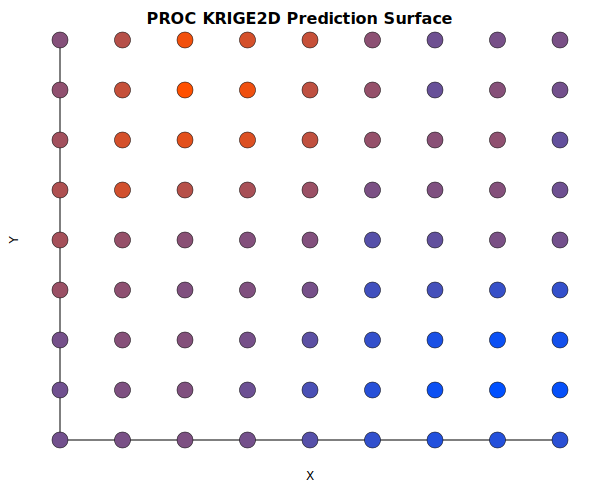

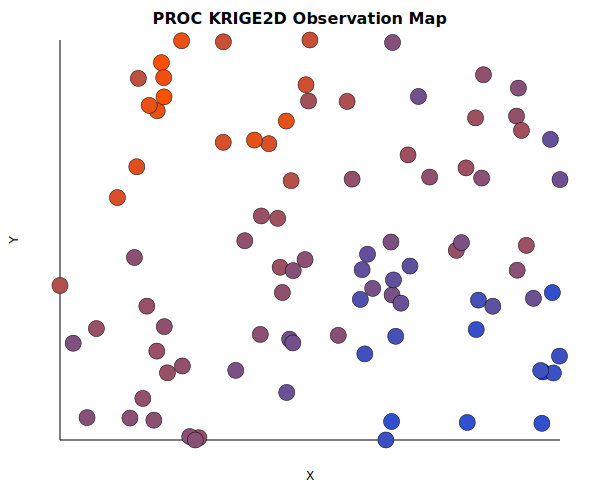

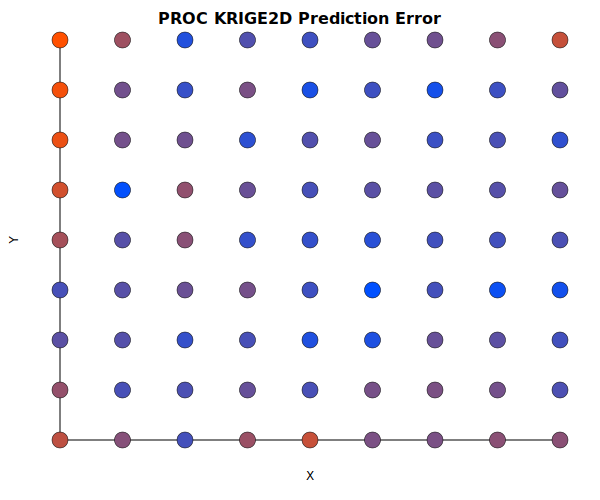

In [3]:
PROCEDIMENTO krige2d DADOS=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TÍTULO 'Krigagem Ordinária dos Tempos de Espera do Pronto-Socorro - Modelo Esférico';
   COORDINATES XC=east YC=north;
   predict VARIÁVEL=wait_min radius=20 minpoints=10 maxpoints=40;
   MODELO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 ATÉ 50 POR 6 y=0 ATÉ 50 POR 6;
EXECUTAR;


## Etapa 4 - Inspecionar a superfície krigada

O dataset `OUTEST=` contém uma linha por nó da grade com o tempo de espera previsto (`estimate`) e seu erro padrão de krigagem (`stderr`). Resumimos a superfície e sinalizamos os nós previstos mais quentes - zonas candidatas onde um novo posto de atendimento de urgência aliviaria mais pressão.

A média da superfície krigada (**35,55 minutos**) acompanha a média observada das unidades (35,5) quase exatamente, uma verificação de sanidade de que a krigagem ordinária é não viesada. As predições variam de **16,1** no sudeste esparso a **56,4** no noroeste congestionado; os erros padrão variam de **5,1** onde as unidades são densas a **11,2** nos cantos pouco amostrados da área de cobertura. Os seis nós mais quentes ficam todos no quadrante NO em torno de (12-18, 36-48), exatamente sobre o pico do centro urbano embutido nos dados.

In [4]:
PROCEDIMENTO MÉDIAS DADOS=krige_sph n mean MIN MAX maxdec=2;
   RÓTULO ESTIMATIVA="Estimativa" stderr="Erro Padrão";
   TÍTULO 'Resumo da Superfície Krigada (Minutos de Espera Previstos e Erro Padrão)';
   VARIÁVEL ESTIMATIVA stderr;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=krige_sph out=hot_nodes;
   POR DECRESCENTE ESTIMATIVA;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=hot_nodes(obs=6) noobs RÓTULO;
   RÓTULO x="X" y="Y" ESTIMATIVA="Estimativa" stderr="Erro Padrão";
   TÍTULO 'Seis Nós da Grade com os Maiores Tempos de Espera Previstos no Pronto-Socorro';
   VARIÁVEL x y ESTIMATIVA stderr;
EXECUTAR;


                        Resumo da Superfície Krigada (Minutos de Espera Previstos e Erro Padrão)                        

                                                  The MEANS Procedure

 Variable  Label               N        Mean     Minimum     Maximum
 -------------------------------------------------------------------
 ESTIMATE  Estimativa         81       35.55       16.07       56.38
 STDERR    Erro Padrão        81        7.38        5.06       11.20
 -------------------------------------------------------------------

                     Seis Nós da Grade com os Maiores Tempos de Espera Previstos no Pronto-Socorro                      

 X   Y     Estimativa   Erro Padrão
12  42  56.3838526129  6.3860887297
12  48   54.379464215   5.876759721
18  42    53.81777091  8.0028060667
12  36  51.9499223116  7.7283024845
18  36  50.7825137373  6.1546512678
 6  36  49.6363903072  7.8641112964

... 75 more observations (showing 6 of 81)




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Etapa 5 - Predizer em locais candidatos específicos

O planejamento de rede tem três locais propostos para atendimento de urgência. Krigamos diretamente em cada ponto fornecendo-o como uma grade de nó único (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), dando aos planejadores o tempo de espera previsto e seu erro padrão de krigagem na coordenada exata.

O candidato mais próximo do núcleo central urbano, **(14, 37)**, retorna a maior espera prevista - **52,2 +/- 7,3 minutos** - confirmando que ele absorveria demanda dos PS mais movimentados. O candidato sudeste **(32, 12)** fica no canto suburbano tranquilo com **22,0 +/- 6,2**, e o candidato nordeste **(42, 44)** fica em faixa intermediária com **36,4 +/- 5,9**. Considerando apenas a espera prevista, o candidato do centro urbano é o caso mais forte, baseado em evidências, para a instalação.

In [5]:
PROCEDIMENTO krige2d DADOS=ed_sites outest=cand_dt PLOTS=none;
   TÍTULO 'Candidato A - Núcleo Central (14, 37)';
   COORDINATES XC=east YC=north;
   predict VARIÁVEL=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 ATÉ 14 POR 1 y=37 ATÉ 37 POR 1;
EXECUTAR;

PROCEDIMENTO krige2d DADOS=ed_sites outest=cand_se PLOTS=none;
   TÍTULO 'Candidato B - Subúrbio Sudeste (32, 12)';
   COORDINATES XC=east YC=north;
   predict VARIÁVEL=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 ATÉ 32 POR 1 y=12 ATÉ 12 POR 1;
EXECUTAR;

PROCEDIMENTO krige2d DADOS=ed_sites outest=cand_ne PLOTS=none;
   TÍTULO 'Candidato C - Extremidade Nordeste (42, 44)';
   COORDINATES XC=east YC=north;
   predict VARIÁVEL=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 ATÉ 42 POR 1 y=44 ATÉ 44 POR 1;
EXECUTAR;

DADOS candidates;
   DEFINIR cand_dt cand_se cand_ne;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=candidates noobs RÓTULO;
   RÓTULO x="X" y="Y" ESTIMATIVA="Estimativa" stderr="Erro Padrão";
   TÍTULO 'Tempos de Espera Previstos do Pronto-Socorro em Três Locais Candidatos para Unidade de Pronto Atendimento';
   VARIÁVEL x y ESTIMATIVA stderr;
EXECUTAR;


                     Seis Nós da Grade com os Maiores Tempos de Espera Previstos no Pronto-Socorro                      

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                     Seis Nós da Grade com os Maiores Tempos de Espera Previstos no Pronto-Socorro                      

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Interpretando os resultados

- **A superfície krigada reproduz a estrutura de congestionamento da área de cobertura.** O modelo esférico de krigagem ordinária interpola um campo suave de tempo de espera cuja média nos nós da grade (35,55 min) corresponde à média observada nas unidades (35,5 min), com as maiores esperas previstas - até 56,4 minutos - concentradas no quadrante NO em torno do pico do centro urbano perto de (15, 38) que embutimos nos dados sintéticos. Essa correspondência é uma verificação de sanidade de que o modelo está se comportando bem.
- **Os erros padrão localizam a confiança.** O erro padrão de krigagem varia de 5,1 minutos onde as unidades são densas a 11,2 nos cantos pouco amostrados da área de cobertura. Os planejadores devem tratar as predições em zonas de `stderr` alto com cautela; essas também são as áreas onde acrescentar uma unidade mais melhoraria tanto a cobertura futura quanto a medição futura.
- **As predições pontuais apoiam decisões de instalação.** Krigar diretamente os três locais candidatos transforma a superfície em uma tabela acionável. O candidato do centro urbano (14, 37) mostra a maior espera prevista (52,2 min) com um erro padrão moderado (7,3), tornando-o o caso mais forte, baseado em evidências, para um novo posto de atendimento de urgência aliviar o PS mais movimentado; o candidato suburbano-sudeste (32, 12) fica em um canto de baixa demanda (22,0 min) e o candidato da borda nordeste (42, 44) fica em faixa intermediária (36,4 min).

Na prática, os parâmetros do semivariograma (`SCALE`, `RANGE`, `NUGGET`) seriam estimados empiricamente com o PROC VARIOGRAM e então passados ao KRIGE2D - seja como valores explícitos, como mostrado aqui, ou automaticamente via `RESTORE` a partir de um item store do VARIOGRAM.